# Maratończycy: analiza w stylu `study + realworld`

Ten notebook rozwija demo `maratonczycy_groupby_pivot_demo.ipynb`, ale w stylu bardziej zbliżonym do:
- `wyklad_analiza_1_study.ipynb`
- `wyklad_analiza_1_realworldexploration.ipynb`

Cel:
1. przygotować dane,
2. obejrzeć rozkłady,
3. zbadać relacje między zmiennymi,
4. zrobić sensowne `groupby` i `pivot_table`,
5. wyciągnąć kilka czytelnych wniosków.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

candidate_paths = [
    Path('marathon-data.csv'),
    Path('/mnt/data/marathon-data.csv'),
    Path('/mnt/data/extracted14/4/4_wyklad_matplotlib/marathon-data.csv'),
]

DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Nie znaleziono pliku marathon-data.csv')

df = pd.read_csv(DATA_PATH)
print(DATA_PATH)
df.head()


/mnt/data/marathon-data.csv


,age,gender,split,final
0,33,M,01:05:38,02:08:51
1,32,M,01:06:26,02:09:28
2,31,M,01:06:49,02:10:42
3,38,M,01:06:16,02:13:45
4,31,M,01:06:32,02:13:59


## 1. Podstawowy przegląd danych

In [2]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37250 entries, 0 to 37249
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   age     37250 non-null  int64 
 1   gender  37250 non-null  object
 2   split   37250 non-null  object
 3   final   37250 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


In [3]:

df.describe(include='all').transpose()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,37250.0,NaN,NaN,NaN,40.697369,10.220043,17.0,33.0,40.0,48.0,86.0
gender,37250,2,M,24665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
split,37250,6496,01:57:55,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final,37250,13853,04:36:57,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Przygotowanie danych
Konwertujemy czasy na `timedelta` i minuty. Dodajemy też `slowdown_min`, czyli ile minut zawodnik stracił względem idealnie równego tempa na drugiej połowie.

In [4]:

for col in ['split', 'final']:
    df[col + '_td'] = pd.to_timedelta(df[col])
    df[col + '_min'] = df[col + '_td'].dt.total_seconds() / 60

df['slowdown_min'] = df['final_min'] - 2 * df['split_min']
df['slowdown_pct'] = 100 * df['slowdown_min'] / df['final_min']
df['negative_split'] = df['slowdown_min'] < 0

age_bins = [15, 19, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 100]
age_labels = ['16-19', '20-24', '25-29', '30-34', '35-39', '40-44',
              '45-49', '50-54', '55-59', '60-64', '65-69', '70+']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

df.head()


,age,gender,split,final,split_td,split_min,final_td,final_min,slowdown_min,slowdown_pct,negative_split,age_group
0,33,M,01:05:38,02:08:51,0 days 01:05:38,65.633333,0 days 02:08:51,128.850000,-2.416667,-1.875566,True,30-34
1,32,M,01:06:26,02:09:28,0 days 01:06:26,66.433333,0 days 02:09:28,129.466667,-3.400000,-2.626159,True,30-34
2,31,M,01:06:49,02:10:42,0 days 01:06:49,66.816667,0 days 02:10:42,130.700000,-2.933333,-2.244325,True,30-34
3,38,M,01:06:16,02:13:45,0 days 01:06:16,66.266667,0 days 02:13:45,133.750000,1.216667,0.909657,False,35-39
4,31,M,01:06:32,02:13:59,0 days 01:06:32,66.533333,0 days 02:13:59,133.983333,0.916667,0.684165,False,30-34


## 3. Podstawowe statystyki liczbowe

In [5]:

df[['split_min', 'final_min', 'slowdown_min', 'slowdown_pct']].describe().round(2)


,split_min,final_min,slowdown_min,slowdown_pct
count,37250.00,37250.00,37250.00,37250.00
mean,123.91,288.16,40.34,13.09
std,22.92,63.54,23.92,6.18
min,65.35,128.85,-72.47,-23.70
25%,108.42,242.40,22.17,8.83
50%,121.22,284.42,39.35,13.47
75%,136.18,327.60,56.47,17.50
max,299.82,601.13,260.23,57.93


## 4. Funkcje pomocnicze do rozkładu i gęstości

In [6]:

def show_distribution(var_data, title='Rozkład', bins=30):
    fig, ax = plt.subplots(2, 1, figsize=(10, 4))
    ax[0].hist(var_data, bins=bins)
    ax[0].set_title(title)
    ax[0].axvline(var_data.mean(), color='cyan', linestyle='--', linewidth=2, label='mean')
    ax[0].axvline(var_data.median(), color='red', linestyle='--', linewidth=2, label='median')
    ax[0].legend()

    ax[1].boxplot(var_data, vert=False)
    ax[1].set_xlabel('wartość')
    plt.tight_layout()
    plt.show()

def show_density(var_data, title='Gęstość'):
    plt.figure(figsize=(10, 4))
    var_data.plot.density()
    plt.title(title)
    plt.axvline(var_data.mean(), color='cyan', linestyle='--', linewidth=2, label='mean')
    plt.axvline(var_data.median(), color='red', linestyle='--', linewidth=2, label='median')
    plt.legend()
    plt.show()


## 5. Rozkład czasu końcowego

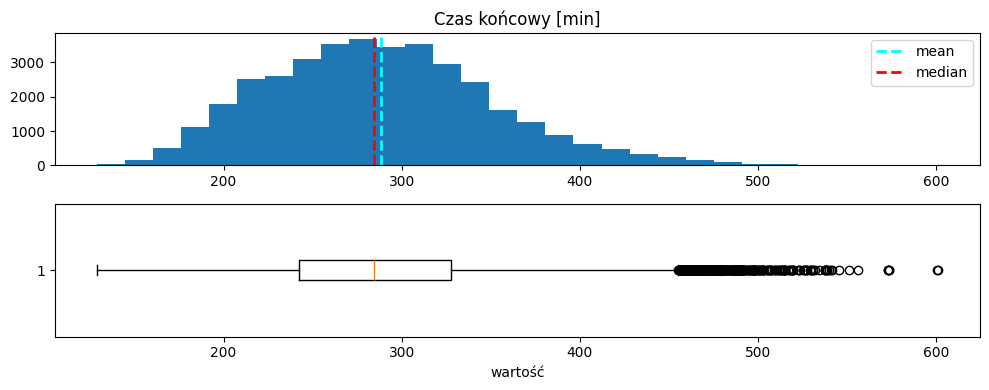

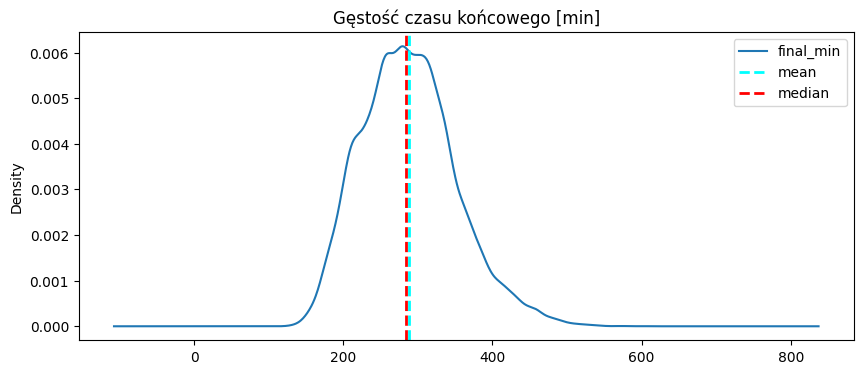

In [7]:

show_distribution(df['final_min'], title='Czas końcowy [min]')
show_density(df['final_min'], title='Gęstość czasu końcowego [min]')


## 6. Histogram i PDF
Krótka ciekawostka statystyczna: histogram jest dyskretny, a PDF to gładkie przybliżenie rozkładu ciągłego.

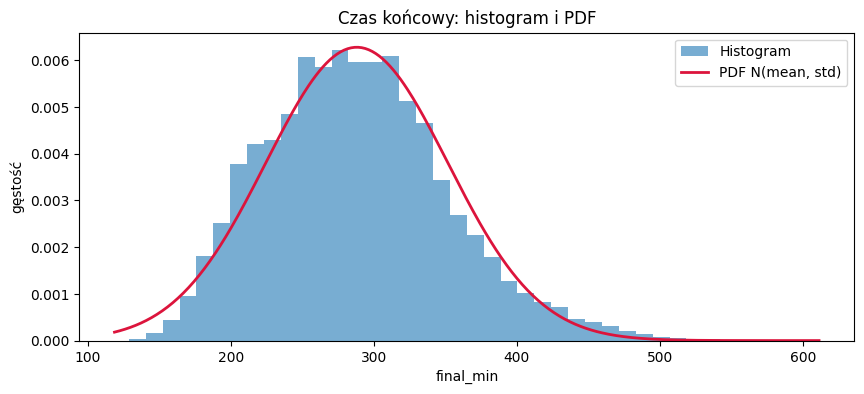

Odsetek biegaczy w zakresie mean ± 1 std: 68.20%


In [8]:

mu = df['final_min'].mean()
sigma = df['final_min'].std(ddof=1)
x = np.linspace(df['final_min'].min() - 10, df['final_min'].max() + 10, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10, 4))
plt.hist(df['final_min'], bins=40, density=True, alpha=0.6, label='Histogram')
plt.plot(x, pdf, color='crimson', linewidth=2, label='PDF N(mean, std)')
plt.title('Czas końcowy: histogram i PDF')
plt.xlabel('final_min')
plt.ylabel('gęstość')
plt.legend()
plt.show()

within_one_sigma = ((df['final_min'] >= mu - sigma) & (df['final_min'] <= mu + sigma)).mean()
print(f'Odsetek biegaczy w zakresie mean ± 1 std: {within_one_sigma:.2%}')


## 7. Rozkład spowolnienia (`slowdown_min`)

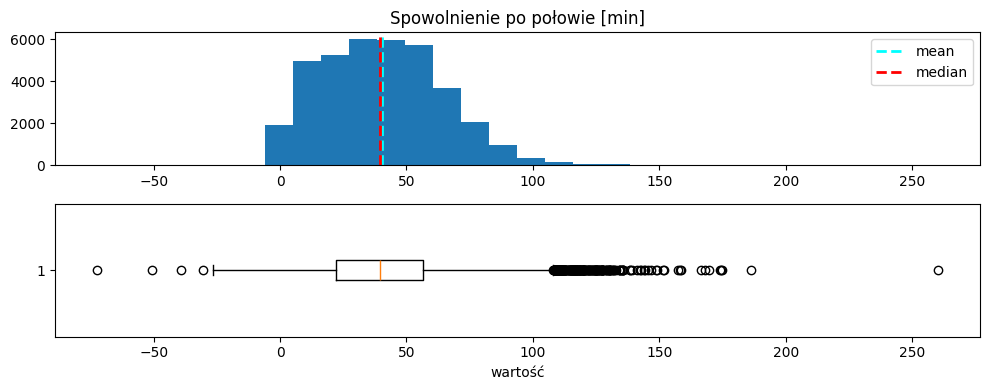

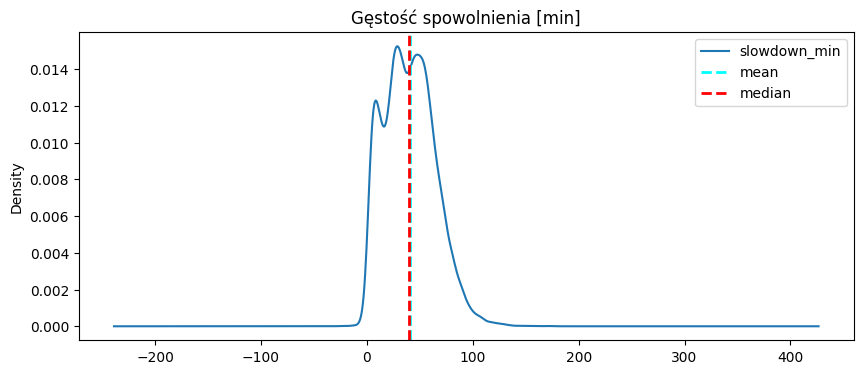

In [9]:

show_distribution(df['slowdown_min'], title='Spowolnienie po połowie [min]')
show_density(df['slowdown_min'], title='Gęstość spowolnienia [min]')


## 8. Relacja między split i final
Tutaj bardzo dobrze działa scatter, korelacja i prosta regresji.

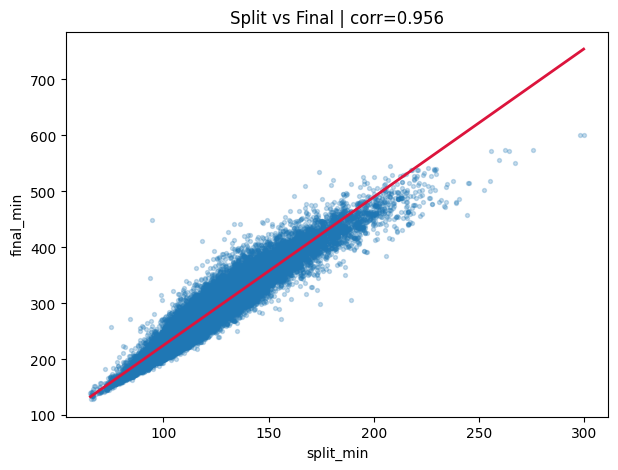

m = 2.6491, b = -40.0905, r = 0.9556, p = 0


In [10]:

corr = df['split_min'].corr(df['final_min'])
m, b, r, p, se = stats.linregress(df['split_min'], df['final_min'])

x_line = np.linspace(df['split_min'].min(), df['split_min'].max(), 200)
y_line = m * x_line + b

plt.figure(figsize=(7, 5))
plt.scatter(df['split_min'], df['final_min'], s=8, alpha=0.25)
plt.plot(x_line, y_line, color='crimson', linewidth=2)
plt.title(f'Split vs Final | corr={corr:.3f}')
plt.xlabel('split_min')
plt.ylabel('final_min')
plt.show()

print(f'm = {m:.4f}, b = {b:.4f}, r = {r:.4f}, p = {p:.4g}')


## 9. Boxplot czasu końcowego względem płci

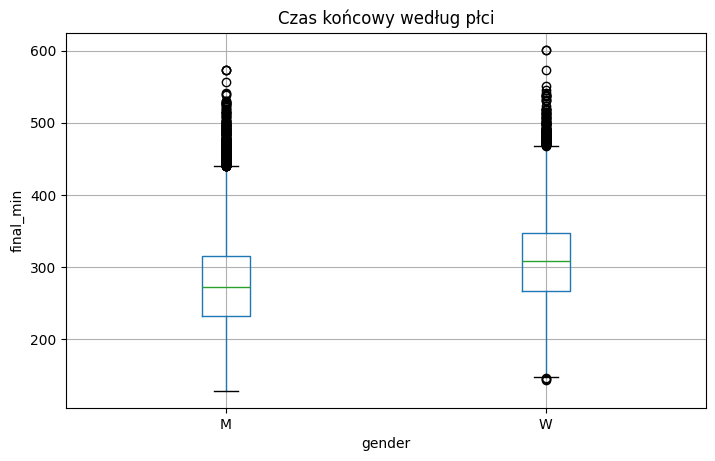

In [11]:

df.boxplot(column='final_min', by='gender', figsize=(8, 5))
plt.title('Czas końcowy według płci')
plt.suptitle('')
plt.xlabel('gender')
plt.ylabel('final_min')
plt.show()


## 10. `groupby`: grupy wiekowe
Liczymy liczebność, średnią, medianę i przeciętne spowolnienie.

In [12]:

age_summary = (
    df.groupby('age_group', observed=False)
      .agg(
          n=('final_min', 'size'),
          mean_final=('final_min', 'mean'),
          median_final=('final_min', 'median'),
          mean_split=('split_min', 'mean'),
          mean_slowdown=('slowdown_min', 'mean'),
          mean_slowdown_pct=('slowdown_pct', 'mean'),
          negative_split_share=('negative_split', 'mean')
      )
      .reset_index()
)

age_summary.round(3)


,age_group,n,mean_final,median_final,mean_split,mean_slowdown,mean_slowdown_pct,negative_split_share
0,16-19,131,300.768,290.933,127.562,45.643,14.630,0.000
1,20-24,1196,287.348,287.892,122.291,42.766,13.894,0.008
2,25-29,4246,284.860,282.733,122.266,40.327,13.189,0.010
3,30-34,5608,281.002,277.675,121.075,38.852,12.845,0.011
4,35-39,6386,282.096,278.683,121.670,38.756,12.764,0.005
5,40-44,6857,280.559,277.367,121.311,37.936,12.577,0.007
6,45-49,5406,286.519,282.142,123.507,39.506,12.929,0.005
7,50-54,3796,296.551,293.450,127.149,42.253,13.455,0.004
8,55-59,2021,309.561,306.133,132.094,45.372,13.986,0.004
9,60-64,1065,328.888,321.117,138.975,50.939,14.988,0.002


## 11. Które grupy wiekowe są najszybsze?

In [13]:

print('Ranking po średniej:')
display(age_summary.sort_values('mean_final').head(5).round(2))

print('Ranking po medianie:')
display(age_summary.sort_values('median_final').head(5).round(2))


Ranking po średniej:


,age_group,n,mean_final,median_final,mean_split,mean_slowdown,mean_slowdown_pct,negative_split_share
5,40-44,6857,280.56,277.37,121.31,37.94,12.58,0.01
3,30-34,5608,281.00,277.67,121.08,38.85,12.85,0.01
4,35-39,6386,282.10,278.68,121.67,38.76,12.76,0.01
2,25-29,4246,284.86,282.73,122.27,40.33,13.19,0.01
6,45-49,5406,286.52,282.14,123.51,39.51,12.93,0.00


Ranking po medianie:


,age_group,n,mean_final,median_final,mean_split,mean_slowdown,mean_slowdown_pct,negative_split_share
5,40-44,6857,280.56,277.37,121.31,37.94,12.58,0.01
3,30-34,5608,281.00,277.67,121.08,38.85,12.85,0.01
4,35-39,6386,282.10,278.68,121.67,38.76,12.76,0.01
6,45-49,5406,286.52,282.14,123.51,39.51,12.93,0.00
2,25-29,4246,284.86,282.73,122.27,40.33,13.19,0.01


## 12. Uwaga na wiarygodność: liczebność grup
To jest bardzo ważny niuans interpretacyjny.

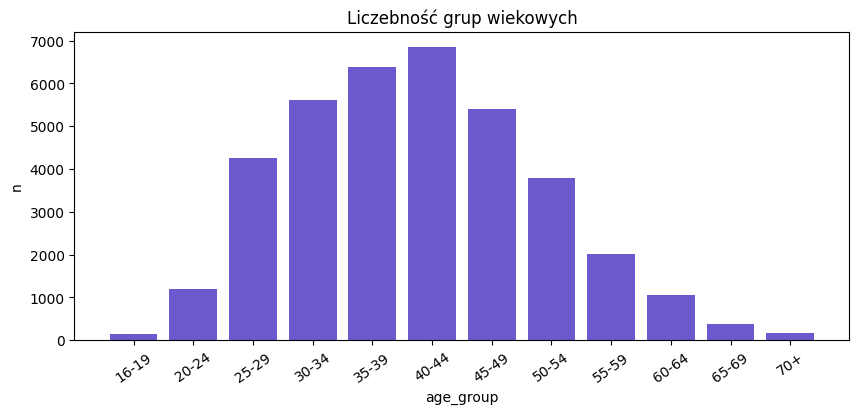

,age_group,n
0,16-19,131
1,20-24,1196
2,25-29,4246
3,30-34,5608
4,35-39,6386
5,40-44,6857
6,45-49,5406
7,50-54,3796
8,55-59,2021
9,60-64,1065


In [14]:

plt.figure(figsize=(10, 4))
plt.bar(age_summary['age_group'].astype(str), age_summary['n'], color='slateblue')
plt.title('Liczebność grup wiekowych')
plt.xlabel('age_group')
plt.ylabel('n')
plt.xticks(rotation=35)
plt.show()

age_summary[['age_group', 'n']].round(0)


## 13. `pivot_table`: wiek × płeć

In [15]:

pivot_mean = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='final_min',
    aggfunc='mean',
    observed=False
)

pivot_median = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='final_min',
    aggfunc='median',
    observed=False
)

pivot_count = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='final_min',
    aggfunc='size',
    observed=False
)

print('Średnia:')
display(pivot_mean.round(2))
print('Mediana:')
display(pivot_median.round(2))
print('Liczebność:')
display(pivot_count)


Średnia:


gender,M,W
age_group,,
16-19,292.80,316.53
20-24,274.63,302.79
25-29,268.16,301.65
30-34,266.00,303.60
35-39,269.23,307.29
40-44,268.83,306.00
45-49,273.75,316.94
50-54,285.48,328.02
55-59,299.49,345.22


Mediana:


gender,M,W
age_group,,
16-19,285.27,317.28
20-24,275.49,302.34
25-29,264.60,301.33
30-34,261.12,302.68
35-39,264.62,305.75
40-44,265.20,304.67
45-49,270.23,316.21
50-54,282.03,321.23
55-59,297.64,336.55


Liczebność:


gender,M,W
age_group,,
16-19,87,44
20-24,656,540
25-29,2129,2117
30-34,3370,2238
35-39,4227,2159
40-44,4693,2164
45-49,3808,1598
50-54,2808,988
55-59,1576,445


## 14. `pivot_table` dla spowolnienia

In [16]:

pivot_slow = pd.pivot_table(
    df,
    index='age_group',
    columns='gender',
    values='slowdown_min',
    aggfunc='mean',
    observed=False
)

pivot_slow.round(2)


gender,M,W
age_group,,
16-19,43.80,49.29
20-24,41.50,44.30
25-29,37.36,43.31
30-34,35.93,43.24
35-39,36.05,44.05
40-44,35.70,42.79
45-49,37.15,45.12
50-54,40.03,48.58
55-59,43.93,50.49


## 15. Wykres liniowy: średnia i mediana po grupach

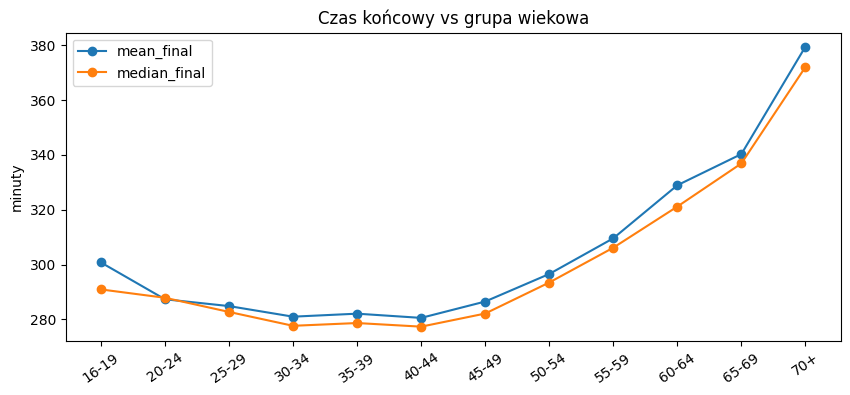

In [17]:

plt.figure(figsize=(10, 4))
plt.plot(age_summary['age_group'].astype(str), age_summary['mean_final'], marker='o', label='mean_final')
plt.plot(age_summary['age_group'].astype(str), age_summary['median_final'], marker='o', label='median_final')
plt.xticks(rotation=35)
plt.ylabel('minuty')
plt.title('Czas końcowy vs grupa wiekowa')
plt.legend()
plt.show()


## 16. Wykres słupkowy: średni wynik `age_group × gender`

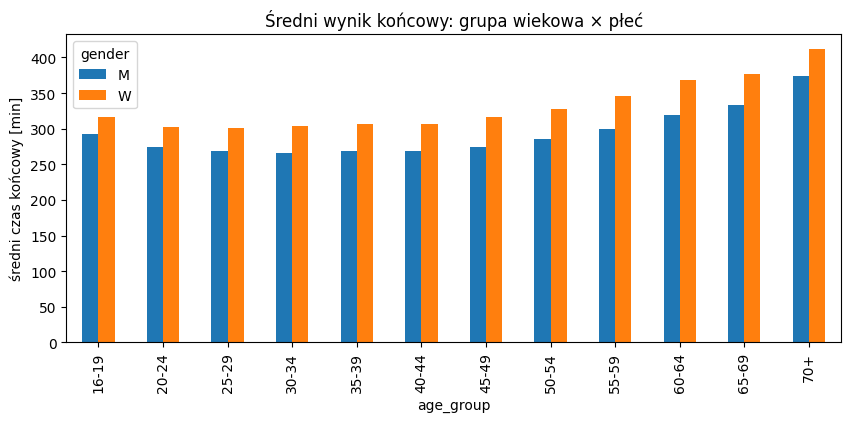

In [18]:

pivot_mean.round(2).plot(kind='bar', figsize=(10, 4))
plt.ylabel('średni czas końcowy [min]')
plt.title('Średni wynik końcowy: grupa wiekowa × płeć')
plt.show()


## 17. Error bars po grupach wiekowych
Średnia bez rozrzutu bywa myląca, więc dokładamy odchylenie standardowe.

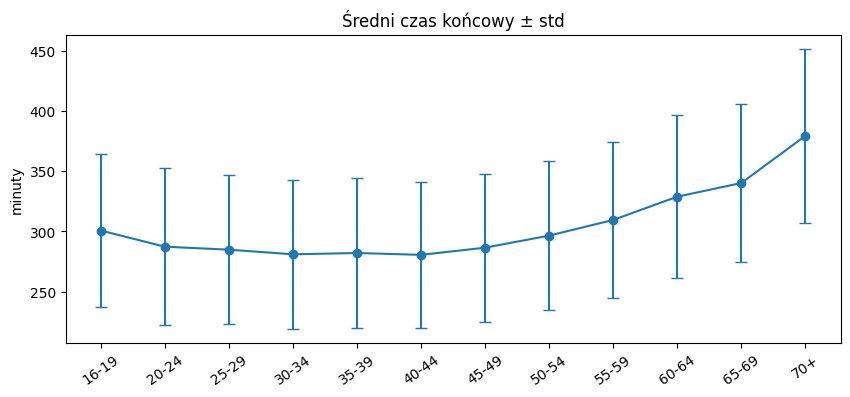

In [19]:

age_err = (
    df.groupby('age_group', observed=False)
      .agg(mean_final=('final_min', 'mean'), std_final=('final_min', 'std'))
      .reset_index()
)

plt.figure(figsize=(10, 4))
plt.errorbar(
    age_err['age_group'].astype(str),
    age_err['mean_final'],
    yerr=age_err['std_final'],
    fmt='o-',
    capsize=4
)
plt.xticks(rotation=35)
plt.title('Średni czas końcowy ± std')
plt.ylabel('minuty')
plt.show()


## 18. Adnotacja na wykresie
Warto czasem podpisać najciekawszy punkt.

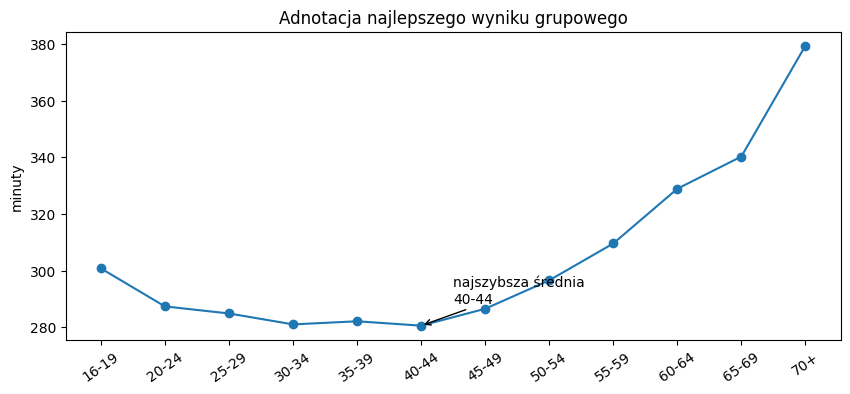

In [20]:

best_row = age_summary.loc[age_summary['mean_final'].idxmin()]

plt.figure(figsize=(10, 4))
plt.plot(age_summary['age_group'].astype(str), age_summary['mean_final'], marker='o')
plt.annotate(
    f"najszybsza średnia\n{best_row['age_group']}",
    xy=(age_summary['age_group'].astype(str)[best_row.name], best_row['mean_final']),
    xytext=(best_row.name + 0.5, best_row['mean_final'] + 8),
    arrowprops=dict(arrowstyle='->')
)
plt.xticks(rotation=35)
plt.ylabel('minuty')
plt.title('Adnotacja najlepszego wyniku grupowego')
plt.show()


## 19. Krótkie wnioski
Nie chodzi o to, żeby znaleźć jedną „prawdziwą” odpowiedź, tylko żeby pokazać studentom spójny workflow: opis, relacja, grupowanie, pivot, interpretacja.

In [21]:

summary_points = {
    'najszybsza_grupa_srednia': age_summary.sort_values('mean_final').iloc[0]['age_group'],
    'najszybsza_grupa_mediana': age_summary.sort_values('median_final').iloc[0]['age_group'],
    'najwieksze_spowolnienie_srednio': age_summary.sort_values('mean_slowdown', ascending=False).iloc[0]['age_group'],
    'korelacja_split_final': round(corr, 3),
    'odsetek_negative_split': round(df['negative_split'].mean() * 100, 2)
}
summary_points


{'najszybsza_grupa_srednia': '40-44',
 'najszybsza_grupa_mediana': '40-44',
 'najwieksze_spowolnienie_srednio': '70+',
 'korelacja_split_final': np.float64(0.956),
 'odsetek_negative_split': np.float64(0.67)}

## 20. Pytania / ćwiczenia dla studentów

1. Która grupa wiekowa jest najszybsza po średniej, a która po medianie?  
2. Czy ranking zmienia się po rozbiciu na płeć?  
3. Które grupy najbardziej zwalniają po połowie dystansu?  
4. Dlaczego sama średnia może być myląca bez liczebności grup?  
5. Jak zmieni się interpretacja, jeśli zamiast `mean` użyjemy `median`?


In [22]:
# TODO dla studentów:
# 1. Zrób pivot_table dla negative_split po age_group i gender
# 2. Posortuj age_summary po mean_slowdown_pct
# 3. Narysuj własny wykres porównujący kobiety i mężczyzn w grupach wiekowych